In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
import time
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
class CrashState(TypedDict):
    input:str
    step1:str
    step2:str
    step3:str

In [3]:
def step_1(state:CrashState)->CrashState:
    print(" Step 1 executed")
    return {"step1":"done","input":state["input"]}

def step_2(state:CrashState)->CrashState:
    print(" Step 2 hanging..., now manually interrupt from the notebook like Ctrl+C")
    time.sleep(30) #Simulate long running hang
    return {"step2":"done"}

def step_3(state:CrashState)->CrashState:
    print(" Step 3 executed")
    return {"step3":"done"}

In [6]:
graph  = StateGraph(CrashState)
graph.add_node("step_1",step_1)
graph.add_node("step_2",step_2)
graph.add_node("step_3",step_3)

graph.add_edge(START,"step_1")
graph.add_edge("step_1","step_2")
graph.add_edge("step_2","step_3")
graph.add_edge("step_3",END)
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

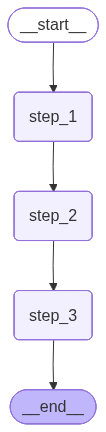

In [9]:
workflow

In [12]:
try:
    print("Running graph: please manually interrupt during Step 2...")
    workflow.invoke({"input":"start"},config = {"configurable":{"thread_id": 'thread-2'}})
except:
    print("Kernel manually interrupted(crash simulated).")

Running graph: please manually interrupt during Step 2...
 Step 1 executed
 Step 2 hanging..., now manually interrupt from the notebook like Ctrl+C
Kernel manually interrupted(crash simulated).


In [11]:
workflow.get_state({"configurable": {"thread_id":'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f121b4e-85a3-6d97-8006-073ddf1d327a'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-03-17T03:53:50.125403+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f121b4e-859d-6ed4-8005-103a70a13a89'}}, tasks=(), interrupts=())

In [13]:
workflow.get_state({"configurable": {"thread_id":'thread-2'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b5a-e362-62dd-8001-69b4755f2c77'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-17T03:59:22.076491+00:00', parent_config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b5a-e35c-6dd1-8000-d0720b0632c8'}}, tasks=(PregelTask(id='bdc6a032-6a25-a08f-9182-0ef317e839bd', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [16]:
list(workflow.get_state_history({"configurable": {"thread_id":'thread-2'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b5a-e362-62dd-8001-69b4755f2c77'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-17T03:59:22.076491+00:00', parent_config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b5a-e35c-6dd1-8000-d0720b0632c8'}}, tasks=(PregelTask(id='bdc6a032-6a25-a08f-9182-0ef317e839bd', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b5a-e35c-6dd1-8000-d0720b0632c8'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-17T03:59:22.075489+00:00', parent_config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'ch

In [17]:
workflow.invoke(None,config = {"configurable":{"thread_id": 'thread-2'}})

 Step 2 hanging..., now manually interrupt from the notebook like Ctrl+C
 Step 3 executed


{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}

In [18]:
list(workflow.get_state_history({"configurable": {"thread_id":'thread-2'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b64-924f-6041-8003-75a4bf0fb773'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-17T04:03:42.011808+00:00', parent_config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b64-924a-6278-8002-7fb584636c99'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b64-924a-6278-8002-7fb584636c99'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-17T04:03:42.009816+00:00', parent_config={'configurable': {'thread_id': 'thread-2', 'checkpoint_ns': '', 'checkpoint_id': '1f121b5a-e362-62dd-8001-69b4755f2c77'}}, tasks=(PregelTask(id='ca658934-188f-79aa